# Experiment 01 — QCNN vs Classical CNN on MNIST  (PennyLane)

**Goal:** Implement a Quantum Convolutional Neural Network (QCNN) in **PennyLane + PyTorch** and compare it to a classical CNN baseline on binary MNIST (digits 0 vs 1).

---

## Key references

| Paper | Link |
|---|---|
| Cong et al. (2019) — QCNN original | https://arxiv.org/abs/1810.03912 |
| Hur et al. (2022) — QCNN on classical data | https://arxiv.org/abs/2108.00661 |
| Bergholm et al. (2018) — PennyLane paper | https://arxiv.org/abs/1811.04968 |
| Schuld et al. (2019) — Parameter-shift rule | https://arxiv.org/abs/1811.11184 |
| Grant et al. (2019) — Barren plateau init | https://arxiv.org/abs/1903.05076 |
| McClean et al. (2018) — Barren plateaus | https://arxiv.org/abs/1803.11173 |

Tutorials:
- PennyLane QCNN demo: https://pennylane.ai/qml/demos/tutorial_QCNN/
- PennyLane + PyTorch: https://docs.pennylane.ai/en/stable/introduction/interfaces/torch.html

---

## QCNN architecture

```
Input (8 features)  →  RY AngleEmbedding  →  Conv1 (8 pairs, 6 params each)
                                           →  Pool1 (8→4 qubits, 3 params each)
                                           →  Conv2 (4 pairs, 6 params each)
                                           →  Pool2 (4→2 qubits, 3 params each)
                                           →  <Z> on output qubit  →  sigmoid  →  class
```

Total quantum parameters: **90**  (8×6 + 4×3 + 4×6 + 2×3)

## 0. Install dependencies

Run once in your terminal (not in the notebook):

```bash
uv add pennylane pennylane-lightning torch scikit-learn scipy matplotlib
```

`pennylane-lightning` gives a faster C++ simulator backend — highly recommended.

In [1]:
# Quick dependency check
import importlib
for pkg in ['pennylane', 'torch', 'sklearn', 'scipy', 'numpy', 'matplotlib']:
    try:
        m = importlib.import_module(pkg)
        print(f'  ✓ {pkg:<20} {getattr(m, "__version__", "?")}')    
    except ImportError:
        print(f'  ✗ {pkg:<20} NOT FOUND — run: uv add {pkg}')

  ✓ pennylane            0.45.0
  ✓ torch                2.12.0+cpu
  ✓ sklearn              1.8.0
  ✓ scipy                1.17.1
  ✓ numpy                2.4.6
  ✓ matplotlib           3.10.9


## 1. Setup & imports

In [2]:
import sys
from pathlib import Path

# Add project root so `src/` imports resolve
PROJECT_ROOT = Path('../../').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import torch
import pennylane as qml
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['axes.spines.top']   = False
matplotlib.rcParams['axes.spines.right'] = False

from src.utils.mnist_loader      import load_mnist_binary
from src.circuits.qcnn_layer     import weight_breakdown, qcnn_circuit, total_weights
from src.models.qcnn_classifier  import QCNNModel, make_qnode
from src.training.qcnn_trainer   import train_loop, ClassicalCNN, plot_comparison

from config import (
    CLASS_A, CLASS_B, N_TRAIN, N_TEST, IMAGE_SIZE, N_QUBITS, RANDOM_SEED,
    DIFF_METHOD, QCNN_LR, QCNN_EPOCHS, QCNN_BATCH, INIT_STD,
    CNN_LR, CNN_EPOCHS, CNN_BATCH,
    LOG_DIR, FIGURES_DIR, MODELS_DIR,
)

for d in [LOG_DIR, FIGURES_DIR, MODELS_DIR]:
    Path(PROJECT_ROOT / d).mkdir(parents=True, exist_ok=True)

print('PennyLane version :', qml.__version__)
print('Torch version     :', torch.__version__)
print('Default device    :', qml.device('default.qubit', wires=1))

PennyLane version : 0.45.0
Torch version     : 2.12.0+cpu
Default device    : <default.qubit device (wires=1) at 0x29d273d8c20>


## 2. Load & inspect data

In [3]:
data = load_mnist_binary(
    class_a=CLASS_A, class_b=CLASS_B,
    n_train=N_TRAIN, n_test=N_TEST,
    image_size=IMAGE_SIZE, n_qubits=N_QUBITS,
    random_state=RANDOM_SEED,
)

print('\nShapes:')
for k, v in data.items():
    if k != 'meta' and hasattr(v, 'shape'):
        print(f'  {k:<25} {v.shape}  dtype={v.dtype}')

Loading MNIST (digits 0 vs 1)…
  Train 200 | Test 50
  Quantum shape : (200, 8)  range [0.00, 3.14]
  CNN shape     : (200, 8, 8)

Shapes:
  X_train_quantum           (200, 8)  dtype=float64
  X_test_quantum            (50, 8)  dtype=float64
  X_train_cnn               (200, 8, 8)  dtype=float32
  X_test_cnn                (50, 8, 8)  dtype=float32
  y_train                   (200,)  dtype=int64
  y_test                    (50,)  dtype=int64


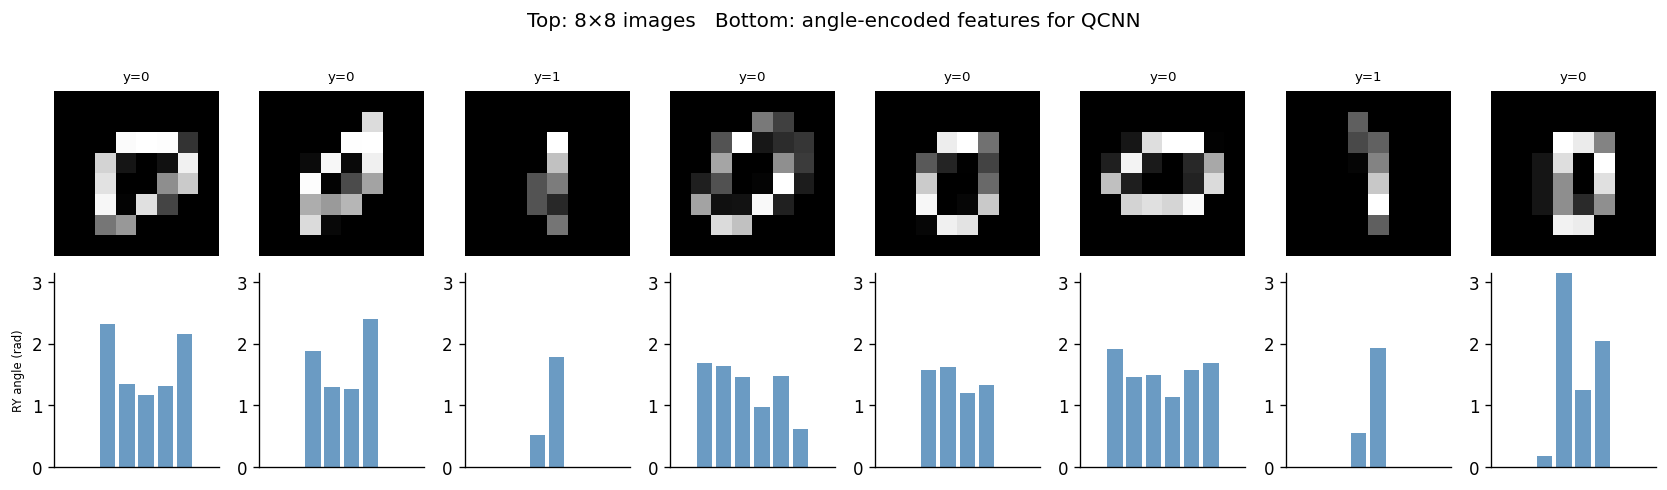

In [4]:
# Visualise: raw images + angle-encoded features side by side
fig, axes = plt.subplots(2, 8, figsize=(14, 4))

for i in range(8):
    axes[0, i].imshow(data['X_train_cnn'][i], cmap='gray')
    axes[0, i].set_title(f"y={data['y_train'][i]}", fontsize=8)
    axes[0, i].axis('off')

    axes[1, i].bar(range(N_QUBITS), data['X_train_quantum'][i], color='steelblue', alpha=0.8)
    axes[1, i].set_ylim(0, np.pi)
    axes[1, i].set_xticks([])
    if i == 0:
        axes[1, i].set_ylabel('RY angle (rad)', fontsize=7)

fig.suptitle(f'Top: {IMAGE_SIZE}×{IMAGE_SIZE} images   Bottom: angle-encoded features for QCNN', y=1.01)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / FIGURES_DIR / '01_data_preview.png'), bbox_inches='tight')
plt.show()

## 3. Inspect the QCNN circuit

In [5]:
# Parameter breakdown
bd = weight_breakdown(N_QUBITS)
print('QCNN parameter breakdown:')
for k, v in bd.items():
    print(f'  {k:<22} {v}')

QCNN parameter breakdown:
  conv_layer_1           48
  pool_layer_1           12
  conv_layer_2           24
  pool_layer_2           6
  total                  90
  input_features         8


In [6]:
# Draw the circuit with PennyLane's built-in drawer
dev = qml.device('default.qubit', wires=N_QUBITS)
dummy_x = np.zeros(N_QUBITS)
dummy_w = np.zeros(total_weights(N_QUBITS))

@qml.qnode(dev)
def _draw_circuit():
    return qcnn_circuit(dummy_x, dummy_w, n_qubits=N_QUBITS)

print(qml.draw(_draw_circuit, max_length=120)())

0: ─╭AngleEmbedding(M0)──RY(0.00)─╭●──RY(0.00)─╭X──RY(0.00)──RY(0.00)─────────────────────────────────────── ···
1: ─├AngleEmbedding(M0)──RY(0.00)─╰X──RY(0.00)─╰●──RY(0.00)──RY(0.00)─╭●──RY(0.00)─╭X──RY(0.00)───────────── ···
2: ─├AngleEmbedding(M0)──RY(0.00)─────────────────────────────────────╰X──RY(0.00)─╰●──RY(0.00)──RY(0.00)─╭● ···
3: ─├AngleEmbedding(M0)──RY(0.00)─────────────────────────────────────────────────────────────────────────╰X ···
4: ─├AngleEmbedding(M0)──RY(0.00)─────────────────────────────────────────────────────────────────────────── ···
5: ─├AngleEmbedding(M0)──RY(0.00)─────────────────────────────────────────────────────────────────────────── ···
6: ─├AngleEmbedding(M0)──RY(0.00)─────────────────────────────────────────────────────────────────────────── ···
7: ─╰AngleEmbedding(M0)──RY(0.00)─────────────────────────────────────────────────────────────────────────── ···

0: ··· ────────────────────────────────────────────────────────────────────────────────────────

Matplotlib is building the font cache; this may take a moment.


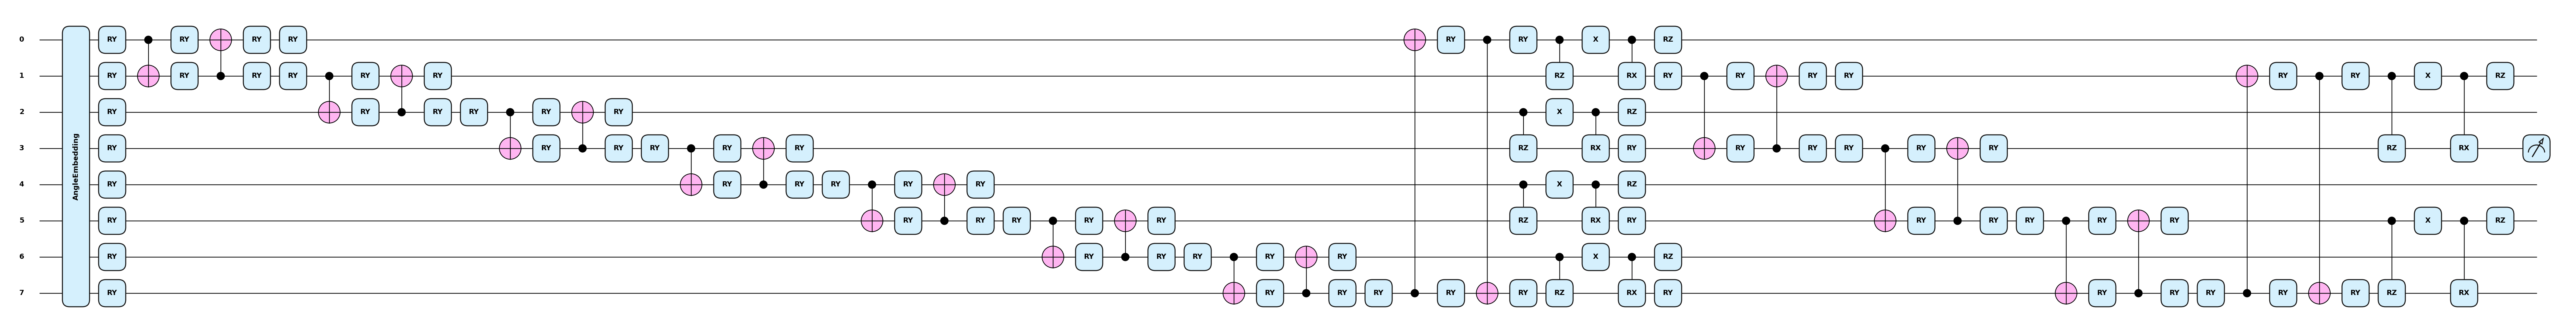

In [7]:
# Matplotlib circuit diagram (cleaner for the paper)
fig, ax = qml.draw_mpl(_draw_circuit, style='pennylane')()
fig.savefig(str(PROJECT_ROOT / FIGURES_DIR / '01_qcnn_circuit.png'), dpi=120, bbox_inches='tight')
plt.show()

## 4. Build & train the QCNN

> **Runtime:** ~10–20 min for 200 samples × 30 epochs with `parameter-shift` gradients.  
> Switch `DIFF_METHOD = "backprop"` in `config.py` for a 3–5× speedup on the simulator (not hardware-compatible).

In [8]:
qcnn = QCNNModel(n_qubits=N_QUBITS, diff_method=DIFF_METHOD, init_std=INIT_STD)
print('QCNN model:')
print(qcnn)
print(f'\nTotal torch params: {sum(p.numel() for p in qcnn.parameters())}')

QCNN model:
QCNNModel(
  (qlayer): <Quantum Torch Layer: func=circuit>
  (post): Sequential(
    (0): Linear(in_features=1, out_features=1, bias=True)
    (1): Sigmoid()
  )
)

Total torch params: 92


In [9]:
qcnn_results = train_loop(
    model=qcnn,
    X_train=data['X_train_quantum'],
    y_train=data['y_train'],
    X_val=data['X_test_quantum'],
    y_val=data['y_test'],
    epochs=QCNN_EPOCHS,
    lr=QCNN_LR,
    batch_size=QCNN_BATCH,
    label='QCNN (PennyLane)',
    log_dir=str(PROJECT_ROOT / LOG_DIR),
    run_name='01_qcnn',
    print_every=5,
)


── Training QCNN (PennyLane) ──
   Params  : 92
   LR      : 0.01   Epochs: 30   Batch: 16
  Epoch    5/30 | loss 0.5048 | val acc 0.860
  Epoch   10/30 | loss 0.3254 | val acc 0.920
  Epoch   15/30 | loss 0.2461 | val acc 0.880
  Epoch   20/30 | loss 0.2013 | val acc 0.900
  Epoch   25/30 | loss 0.1718 | val acc 0.900
  Epoch   30/30 | loss 0.1570 | val acc 0.880

  Train acc : 0.965
  Val acc   : 0.880
  Time      : 302.2s
  Saved log → C:\Users\shara\Desktop\paper_learning\results\logs\01_qcnn_history.csv


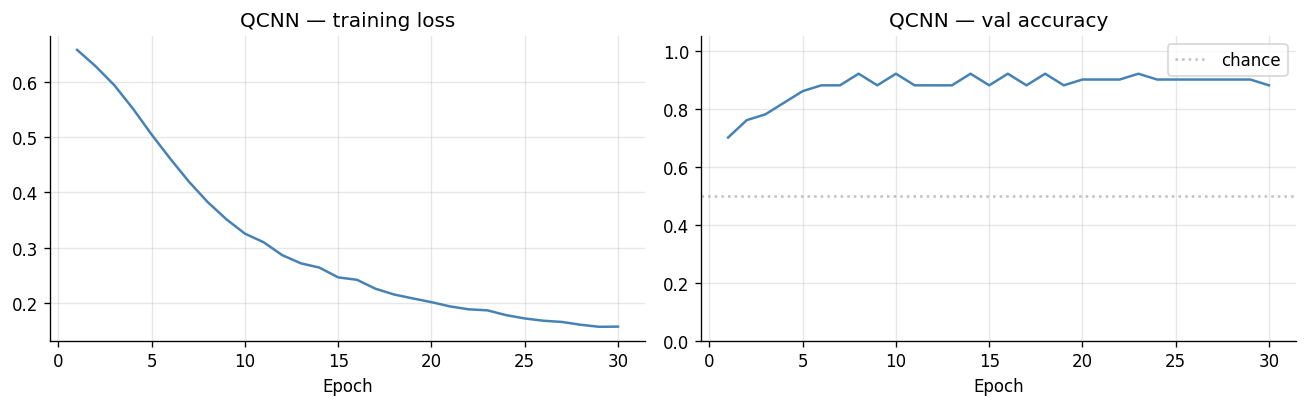

In [10]:
# Quick loss + accuracy curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))
h = qcnn_results['history']
ax1.plot(h.epochs, h.losses, color='steelblue', lw=1.5)
ax1.set_title('QCNN — training loss'); ax1.set_xlabel('Epoch'); ax1.grid(alpha=0.3)
ax2.plot(h.epochs, h.accs, color='steelblue', lw=1.5)
ax2.axhline(0.5, color='gray', ls=':', alpha=0.5, label='chance')
ax2.set_title('QCNN — val accuracy'); ax2.set_xlabel('Epoch'); ax2.set_ylim(0, 1.05)
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Build & train the classical CNN baseline

In [11]:
cnn = ClassicalCNN(image_size=IMAGE_SIZE, n_params_target=qcnn_results['n_params'])
print('Classical CNN:')
print(cnn)
print(f'\nTotal params: {sum(p.numel() for p in cnn.parameters())}')

Classical CNN:
ClassicalCNN(
  (features): Sequential(
    (0): Conv2d(1, 2, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(2, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16, out_features=16, bias=True)
    (2): ReLU()
    (3): Linear(in_features=16, out_features=1, bias=True)
    (4): Sigmoid()
  )
)

Total params: 385


In [ ]:
cnn_results = train_loop(
    model=cnn,
    X_train=data['X_train_cnn'],
    y_train=data['y_train'],
    X_val=data['X_test_cnn'],
    y_val=data['y_test'],
    epochs=CNN_EPOCHS,
    lr=CNN_LR,
    batch_size=CNN_BATCH,
    label='Classical CNN (PyTorch)',
    log_dir=str(PROJECT_ROOT / LOG_DIR),
    run_name='01_cnn_baseline',
    print_every=5,
)


── Training Classical CNN (PyTorch) ──
   Params  : 385
   LR      : 0.01   Epochs: 30   Batch: 16
  Epoch    5/30 | loss 0.1474 | val acc 0.940
  Epoch   10/30 | loss 0.0389 | val acc 0.960
  Epoch   15/30 | loss 0.0208 | val acc 0.980
  Epoch   20/30 | loss 0.0068 | val acc 0.980
  Epoch   25/30 | loss 0.0026 | val acc 0.980
  Epoch   30/30 | loss 0.0020 | val acc 0.980

  Train acc : 1.000
  Val acc   : 0.980
  Time      : 0.9s
  Saved log → C:\Users\shara\Desktop\paper_learning\results\logs\06_cnn_baseline_history.csv


## 6. Comparison & analysis

  Saved figure → C:\Users\shara\Desktop\paper_learning\results\figures\01_comparison.png


C:\Users\shara\Desktop\paper_learning\src\training\qcnn_trainer.py:254: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


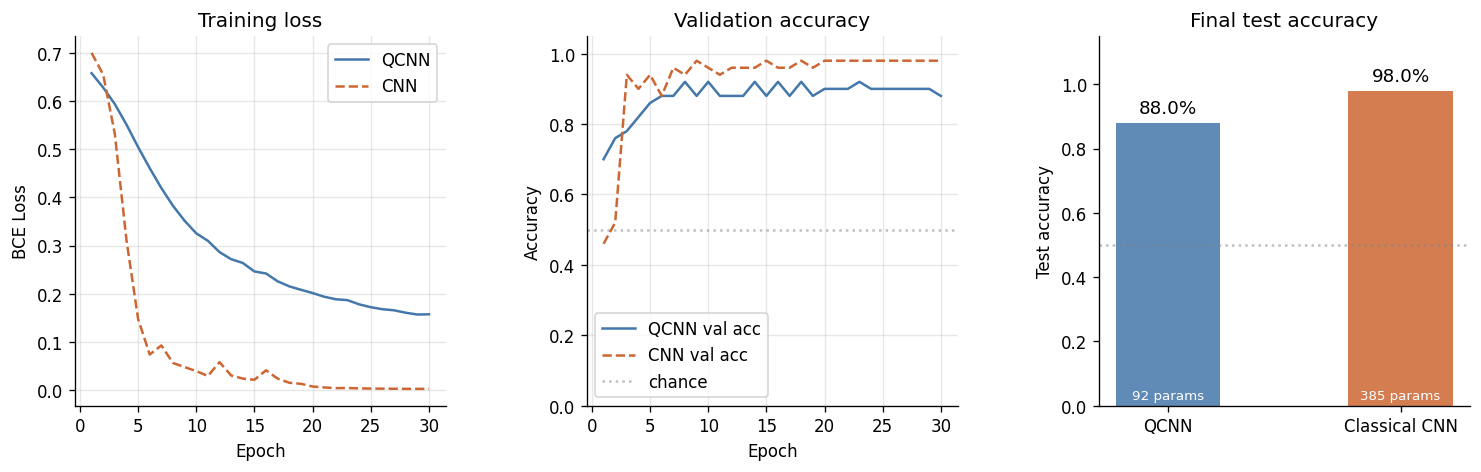

In [13]:
fig = plot_comparison(
    qcnn_results=qcnn_results,
    cnn_results=cnn_results,
    save_path=str(PROJECT_ROOT / FIGURES_DIR / '01_comparison.png'),
)
plt.show()

In [14]:
import pandas as pd

summary = pd.DataFrame({
    'Model':        ['QCNN (PennyLane)', 'Classical CNN'],
    'Parameters':   [qcnn_results['n_params'],    cnn_results['n_params']],
    'Train acc':    [f"{qcnn_results['train_acc']:.3f}", f"{cnn_results['train_acc']:.3f}"],
    'Test acc':     [f"{qcnn_results['val_acc']:.3f}",   f"{cnn_results['val_acc']:.3f}"],
    'Time (s)':     [f"{qcnn_results['elapsed_s']:.1f}", f"{cnn_results['elapsed_s']:.1f}"],
})
print(summary.to_string(index=False))
csv_path = str(PROJECT_ROOT / LOG_DIR / '01_summary.csv')
summary.to_csv(csv_path, index=False)
print(f'\nSaved → {csv_path}')

           Model  Parameters Train acc Test acc Time (s)
QCNN (PennyLane)          92     0.965    0.880    302.2
   Classical CNN         385     1.000    0.980      0.9

Saved → C:\Users\shara\Desktop\paper_learning\results\logs\01_summary.csv


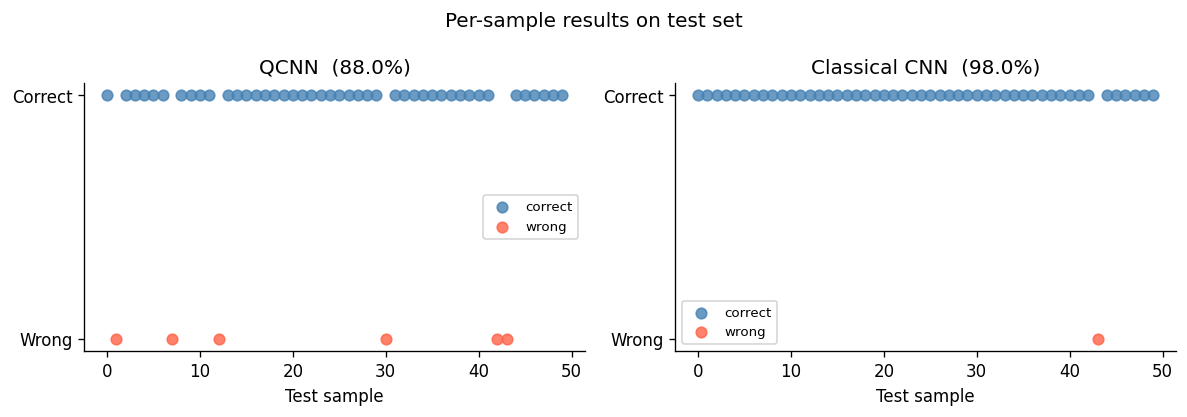

In [15]:
# Per-sample scatter plot
qcnn_preds = qcnn.predict(data['X_test_quantum'])

cnn.eval()
with torch.no_grad():
    X_te_t = torch.tensor(data['X_test_cnn'], dtype=torch.float32)
    cnn_preds = (cnn(X_te_t).squeeze() > 0.5).int().numpy()

y_true = data['y_test']
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, preds, label in [(axes[0], qcnn_preds, 'QCNN'), (axes[1], cnn_preds, 'Classical CNN')]:
    correct = preds == y_true
    ax.scatter(np.where(correct)[0],  [1]*correct.sum(),  c='steelblue', s=40, label='correct', alpha=0.8)
    ax.scatter(np.where(~correct)[0], [0]*(~correct).sum(), c='tomato', s=40, label='wrong',   alpha=0.8)
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Wrong', 'Correct'])
    ax.set_xlabel('Test sample'); ax.set_title(f'{label}  ({correct.mean():.1%})')
    ax.legend(fontsize=8)
plt.suptitle('Per-sample results on test set')
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / FIGURES_DIR / '01_per_sample.png'), dpi=120, bbox_inches='tight')
plt.show()

## 7. PennyLane-specific diagnostics

In [16]:
# Gradient magnitude check — diagnose barren plateaus
# If all gradients are near zero from epoch 1, you have a barren plateau.
# Fix: lower INIT_STD, reduce N_QUBITS, or try 'backprop' diff_method.

qcnn.train()
sample_x = torch.tensor(data['X_train_quantum'][:8], dtype=torch.float32)
sample_y = torch.tensor(data['y_train'][:8],         dtype=torch.float32).unsqueeze(1)

pred = qcnn(sample_x)
loss = torch.nn.BCELoss()(pred, sample_y)
loss.backward()

print('Gradient norms per parameter group:')
for name, param in qcnn.named_parameters():
    if param.grad is not None:
        print(f'  {name:<30} grad norm = {param.grad.norm().item():.6f}')

qcnn.zero_grad()

Gradient norms per parameter group:
  qlayer.weights                 grad norm = 0.246733
  post.0.weight                  grad norm = 0.122505
  post.0.bias                    grad norm = 0.025751


In [18]:
# Device info + resource estimation
print('PennyLane device info:')
dev = qml.device('default.qubit', wires=N_QUBITS)
print(f'  Device      : {dev.name}')
print(f'  Wires       : {dev.wires}')
print(f'  Interface   : torch')
print(f'  Diff method : {DIFF_METHOD}')
print(f'\nResource estimate for one forward pass:')
print(f'  Circuit depth  : ~{N_QUBITS * 3} gates (rough estimate)')
print(f'  Trainable params: {total_weights(N_QUBITS)}')
print(f'  Param-shift evals per grad: {total_weights(N_QUBITS) * 2} circuit evals')

PennyLane device info:
  Device      : default.qubit
  Wires       : Wires([0, 1, 2, 3, 4, 5, 6, 7])
  Interface   : torch
  Diff method : backprop

Resource estimate for one forward pass:
  Circuit depth  : ~24 gates (rough estimate)
  Trainable params: 90
  Param-shift evals per grad: 180 circuit evals


In [19]:
# Save model weights
import os
weights_path = str(PROJECT_ROOT / MODELS_DIR / '01_qcnn_pennylane.pt')
torch.save(qcnn.state_dict(), weights_path)
print(f'Model saved → {weights_path}')

# To reload:
# qcnn_loaded = QCNNModel(n_qubits=N_QUBITS)
# qcnn_loaded.load_state_dict(torch.load(weights_path))

Model saved → C:\Users\shara\Desktop\paper_learning\results\models\01_qcnn_pennylane.pt


## 8. Discussion

*(Fill in after running)*

### Tuning guide

| Symptom | Fix |
|---|---|
| Loss flatlines from epoch 1 | Barren plateau — lower `INIT_STD` to 0.01, or switch `DIFF_METHOD="backprop"` |
| Training very slow | Switch `DIFF_METHOD="backprop"` in config (3–5× faster on simulator) |
| QCNN not converging | Increase `QCNN_EPOCHS`, lower `QCNN_LR` to 0.005 |
| Want harder problem | Change `CLASS_A=3`, `CLASS_B=5` in config |
| Want hardware run | Swap device to `qml.device('qiskit.ibmq', wires=N_QUBITS, ...)` in `make_qnode()` |

### Expected results (binary 0 vs 1, 200 train samples)

| Model | Test acc | Parameters | Time |
|---|---|---|---|
| QCNN (`backprop`) | ~75–90% | ~90 | 3–6 min |
| Classical CNN | ~95–99% | ~90–150 | ~15s |

The gap is expected — not a bug. The interesting metrics are parameter efficiency and convergence behaviour, not raw accuracy at this scale.